In [1]:
from Configurations.imports import *

In [2]:
from Configurations.file_path import base, data_parent_path

In [3]:
file_path = data_parent_path / "height-weight.csv"

### Steps to Perform Linear Regression

#### 1. Data Collection & Loading

Read the dataset and store it in a suitable structure (like a DataFrame).

---

#### 2. Feature Identification

* **Independent variables (X)** → input features
* **Dependent variable (y)** → target/output

---

#### 3. Check Linearity Assumption

* Use **scatter plots** or **correlation matrix**
* Ensure a roughly **linear relationship** exists between X and y

👉 If not linear → linear regression will underperform

---

#### 4. Train-Test Split

Split dataset into:

* **Training set** (to train the model)
* **Testing set** (to evaluate performance)

---

#### 5. Feature Scaling (Standardization)

* Apply **Z-score standardization** on independent features

[
x' = \frac{x - \mu}{\sigma}
]

* Use:

  * `fit_transform()` on training data
  * `transform()` on test data

---

#### 6. Model Training

* Import Linear Regression model
* Fit the model using training data

```python
model.fit(X_train, y_train)
```

---

#### 7. Plot Best Fit Line (for simple regression)

* Visualize:

  * Actual data (scatter plot)
  * Predicted values (regression line)

---

#### 8. Model Evaluation

Evaluate performance using:

* **R² Score**
* **Adjusted R²**
* **MSE (Mean Squared Error)**
* **MAE (Mean Absolute Error)**

---

#### 9. Testing the Model

* Apply model on test data
* Compare predictions with actual values
* Analyze generalization performance

---

#### Takeaway

👉 Linear Regression is not just fitting a line —
it’s about **validating assumptions, scaling correctly, and evaluating properly**.

---


In [5]:
# read the the dataset
df = pd.read_csv(file_path)
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


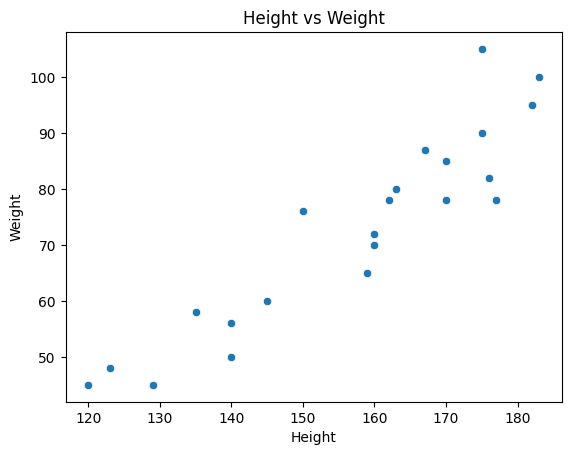

In [9]:
sns.scatterplot(x='Height', y='Weight', data=df)
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

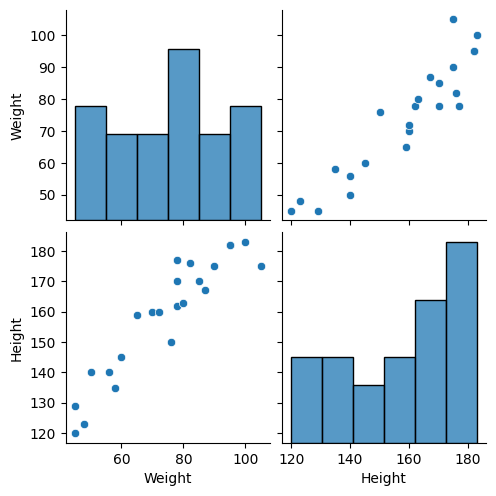

In [12]:
# lets see the correlation
sns.pairplot(df)

In [17]:
# separation of the independent and dependent feature
# x is independent feature dataframe and y is output or dependent feature

x = df[["Weight"]]
y = df["Height"]

In [19]:
# Train Data and Test Data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=42)

In [ ]:
# standardization
#  we modify each value with the z score formula mean is 0 and standard deviation is 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# Apply simple linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [ ]:
regression.coef_ # gives the slope
regression.intercept_ # gives the intercept

np.float64(156.47058823529412)

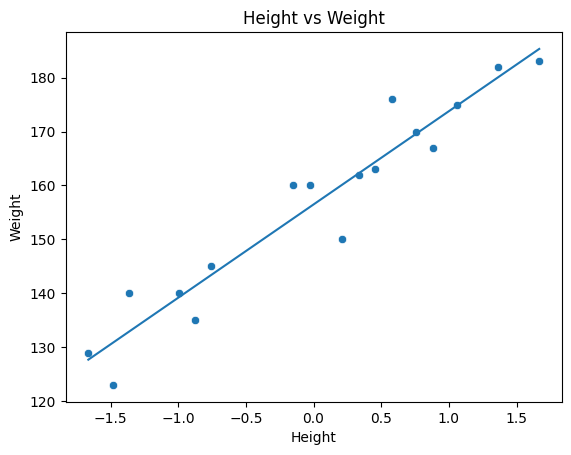

In [37]:
# plotting the regression
sns.scatterplot(x=x_train.flatten(), y=y_train)
sns.lineplot(x=x_train.flatten(), y=regression.predict(x_train))
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

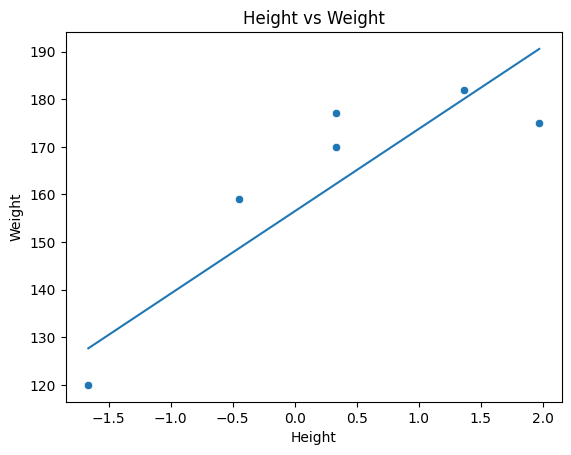

In [ ]:
# model on the test data
sns.scatterplot(x=x_test.flatten(), y=y_test)
sns.lineplot(x=x_test.flatten(), y=regression.predict(x_test))
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [ ]:
 # checking the performance of the model
from sklearn.metrics import r2_score
score = r2_score(y_test, regression.predict(x_test))
score

0.7360826717981276

In [42]:
# adjusted r2_score

adjusted_score = 1 - ((1 - score) * (len(y_test) - 1)) / (len(y_test) - x_test.shape[1] - 1)
adjusted_score

0.6701033397476595

In [ ]:
print("accuracy of the model is: ", adjusted_score * 100)

accuracy of the model is:  67.01033397476594
